In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

True

In [2]:
from datetime import datetime
from deepagents import create_deep_agent
from research_agent.prompts import (
    RESEARCHER_INSTRUCTIONS,
    RESEARCH_WORKFLOW_INSTRUCTIONS,
    SUBAGENT_DELEGATION_INSTRUCTIONS,
)
from research_agent.tools import tavily_search, think_tool
from utils import show_prompt, format_messages
from IPython.display import Image, display
from deepagents.backends.utils import file_data_to_string

In [3]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the research tools provided to you to find resources that can help answer the research      │
│  question.                                                                                                      │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Research Tools>                                                                                     │
│  You have access to two specific research tools:                                                                │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Research Tools>                                                                                    │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

In [4]:
# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Get current date
current_date = datetime.now().strftime("%Y-%m-%d")

# Combine orchestrator instructions (RESEARCH_INSTRUCTIONS only for sub-agent)
INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=current_date),
    "tools": [tavily_search, think_tool],
}

# Model Gemini 3
# model = ChatGoogleGenerativeAI(model="gemini-3-pro-preview", temperature=0.0)

model = ChatOpenAI(
    model=os.getenv("LLM_MODEL_ID"),
    api_key=os.getenv("LLM_API_KEY"),
    base_url=os.getenv("LLM_BASE_URL"),
    temperature=0.0,
)

# Create the agent
agent = create_deep_agent(
    model=model,
    tools=[tavily_search, think_tool],
    system_prompt=INSTRUCTIONS,
    subagents=[research_sub_agent],
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Research Workflow                                                                                            │
│                                                                                                                 │
│  Follow this workflow for all research requests:                                                                │
│                                                                                                                 │
│  1. **Plan**: Create a todo list with write_todos to break down the research into focused tasks                 │
│  2. **Save the request**: Use write_file() to save the user's research question to `/research_request.md`       │
│  3. **Research**: Delegate research tasks to sub-agents using the task() tool - ALWAYS use sub-agents for       │
│  research, never conduct research yourself                                                                      │
│  4. **Synthesize**: Review all sub-agent findings and consolidate citations (each unique URL gets one number    │
│  across all findings)                                                                                           │
│  5. **Write Report**: Write a comprehensive final report to `/final_report.md` (see Report Writing Guidelines   │
│  below)                                                                                                         │
│  6. **Verify**: Read `/research_request.md` and confirm you've addressed all aspects with proper citations and  │
│  structure                                                                                                      │
│                                                                                                                 │
│  ## Research Planning Guidelines                                                                                │
│  - Batch similar research tasks into a single TODO to minimize overhead                                         │
│  - For simple fact-finding questions, use 1 sub-agent                                                           │
│  - For comparisons or multi-faceted topics, delegate to multiple parallel sub-agents                            │
│  - Each sub-agent should research one specific aspect and return findings                                       │
│                                                                                                                 │
│  ## Report Writing Guidelines                                                                                   │
│                                                                                                                 │
│  When writing the final report to `/final_report.md`, follow these structure patterns:                          │
│                                                                                                                 │
│  **For comparisons:**                                                                                           │
│  1. Introduction                                                                                                │
│  2. Overview of topic A                                                                                         │
│  3. Overview of topic B                                                                                         │
│  4. Detailed comparison                                                                                         │
│  5. Conclusion                                                                                                  │
│                                                                                                                 │
│  **For lists/rankings:**                              

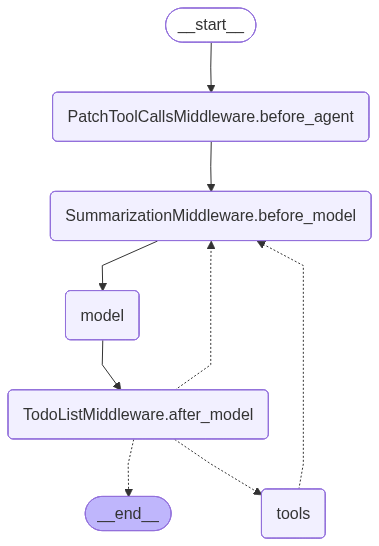

In [5]:
from IPython.display import Image, display

# Show the agent
display(Image(agent.get_graph().draw_mermaid_png()))

In [6]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "research context engineering approaches used to build AI agents",
            }
        ],
    }, 
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ research context engineering approaches used to build AI agents                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save research request to /research_request.md",                                               │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Delegate research on context engineering approaches to sub-agents",                           │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings and assign citations",                                                    │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write comprehensive final report to /final_report.md",                                        │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_c31a00ff26e042daa379e2fc                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "/research_request.md",                                                                          │
│   "content": "Research Topic: Context Engineering Approaches Used to Build AI Agents\n\nKey areas to            │
│ explore:\n1. Prompt engineering techniques for agent contexts\n2. Context window management strategies\n3.      │
│ Memory systems (short-term, long-term, episodic)\n4. RAG (Retrieval Augmented Generation) implementations\n5.   │
│ Context compression and summarization techniques\n6. Multi-agent communication and context sharing              │
│ protocols\n7. Agent architecture patterns that leverage context engineering\n\nGoal: Comprehensive overview of  │
│ how context engineering enables effective AI agent develo

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Save research request to /research_request.md', 'status': 'in_progress'},    │
│ {'content': 'Delegate research on context engineering approaches to sub-agents', 'status': 'pending'},          │
│ {'content': 'Synthesize findings and assign citations', 'status': 'pending'}, {'content': 'Write comprehensive  │
│ final report to /final_report.md', 'status': 'pending'}]                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file /research_request.md                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save research request to /research_request.md",                                               │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Delegate research on context engineering approaches to sub-agents",                           │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings and assign citations",                                                    │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write comprehensive final report to /final_report.md",                                        │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_64a8197357124c50b700caa9                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "Research context engineering approaches for building AI agents. Focus on: 1) Prompt           │
│ engineering techniques specifically for agent contexts, 2) Context window management strategies (how agents     │
│ handle limited context windows), 3) Memory systems including short-term working memory, long-term memory, and   │
│ episodic memory implementations, 4) RAG (Retrieval Augmented Generation) patterns in agent architectures, 5)    │
│ Context compression and summarization techniques used by agents. Provide specific examples, frameworks, and     │
│ best practices. Return a comprehensive report with key findings, techniques, and references to sources.",       │
│   "subagent_type": "general-purpose"                     

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "/final_report.md",                                                                              │
│   "content": "# Context Engineering Approaches for Building AI Agents\n\n## Introduction\n\nContext engineering │
│ represents a fundamental shift in how developers build and deploy AI agents. While traditional prompt           │
│ engineering focused primarily on crafting effective instructions, context engineering encompasses the entire    │
│ input bundle an agent receives\u2014including memory systems, retrieval-augmented generation (RAG), tool        │
│ definitions, conversation history, and execution state [1]. As AI agents evolve from simple chatbots to         │
│ autonomous systems capable of multi-step reasoning and complex task execution, the ability to manage context    │
│ effectively has become the primary determinant of agent reliability and performance.\n\nThis report provides a  │
│ comprehensive overview of context engineering approaches used to build AI agents, covering prompt engineering   │
│ techniques, memory system architectures, RAG implementations, context compression strategies, and multi-agent   │
│ communication protocols. The analysis draws from recent research, production deployments, and open-source       │
│ frameworks that define the current state of the art in agent development.\n\n## The Context Stack               │
│ Architecture\n\nModern AI agents operate on a layered \"context stack\" model rather than relying on a single   │
│ monolithic prompt. This architecture recognizes that different types of information serve different purposes    │
│ and change at different rates:\n\n### Layer 1: System Instructions\n\nSystem instructions define the stable     │
│ behavioral rules for an agent, including its role, domain expertise, tone preferences, safety policies, and     │
│ output format defaults. Effective system prompts are concise\u2014typically under 500 words\u2014and avoid      │
│ duplicating information that belongs in other layers. For example, instead of embedding all tool usage rules in │
│ the system prompt, agents should reference external tool schemas that can be updated independently [1].\n\n###  │
│ Layer 2: Long-Term Memory\n\nLong-term memory stores persistent facts that carry across sessions, such as user  │
│ preferences, past decisions, recurring constraints, and domain knowledge. This layer is typically implemented   │
│ using structured JSON metadata for lightweight facts or vector databases with similarity search for larger      │
│ knowledge bases. The key design principle is to extract reusable information explicitly rather than expecting   │
│ the agent to remember it from conversation history alone [1].\n\n### Layer 3: Retrieved Documents               │
│ (RAG)\n\nRetrieved documents provide dynamically fetched knowledge based on the current query. Best practices   │
│ include retrieving first before prompting, chunking documents intelligently (500-1000 token chunks with         │
│ overlap), and instructing the agent to cite sources by document ID. Pre-filtering and ranking retrieved content │
│ prevents the model from wasting tokens on irrelevant information [1].\n\n### Layer 4: Tool Definitions\n\nTool  │
│ definitions establish the contract between the agent and available functions, including names, descriptions,    │
│ parameters, and usage constraints. Effective tool naming

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file /final_report.md                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save research request to /research_request.md",                                               │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Delegate research on context engineering approaches to sub-agents",                           │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings and assign citations",                                                    │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write comprehensive final report to /final_report.md",                                        │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_3dcbb5e24f3e42ad93213464                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Save research request to /research_request.md', 'status': 'completed'},      │
│ {'content': 'Delegate research on context engineering approaches to sub-agents', 'status': 'completed'},        │
│ {'content': 'Synthesize findings and assign citations', 'status': 'completed'}, {'content': 'Write              │
│ comprehensive final report to /final_report.md', 'status': 'completed'}]                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I've completed a comprehensive research report on **context engineering approaches used to build AI agents**.   │
│ Here's a summary of what was covered:                                                                           │
│                                                                                                                 │
│ ## Key Findings                                                                                                 │
│                                                                                                                 │
│ ### 1. The Context Stack Architecture                                                                           │
│ Modern AI agents operate on a 6-layer context stack rather than single prompts:                                 │
│ - System Instructions (stable behavioral rules)                                                                 │
│ - Long-Term Memory (persistent facts across sessions)                                                           │
│ - Retrieved Documents (RAG results)                                                                             │
│ - Tool Definitions (available functions)                                                                        │
│ - Conversation History (recent turns)                                                                           │
│ - Current Task (immediate request)                                                                              │
│                                                                                                                 │
│ ### 2. Memory System Implementations                                                                            │
│ - **Three-tier architecture**: Short-term (context window), Long-term (vector DBs), Episodic (time-series       │
│ databases)                                                                                                      │
│ - **MemGPT/Letta**: Virtual memory systems creating "infinite context" illusion with 40-60% token reduction     │
│ - **Unified approach**: PostgreSQL + TimescaleDB + pgvector consolidates all memory types                       │
│                                                                                                                 │
│ ### 3. RAG Architectures                                                                                        │
│ Eight major patterns identified, including Simple RAG, Adaptive RAG, Corrective RAG (CRAG), Self-RAG, and       │
│ Agentic RAG. Hybrid search combining vector similarity, keyword search, and temporal filtering is standard      │
│ practice.                                                                                                       │
│                                                                                                                 │
│ ### 4. Context Compression                                                                                      │
│ Structured summarization outperforms unstructured approaches. Evaluation should use probe-based metrics (can    │
│ agent continue working?) rather than lexical similarity. Anchored iterative summarization preserves critical    │
│ artifacts like file paths and function names.                                                                   │
│                                                                                                                 │
│ ### 5. Multi-Agent Communication                                                                                │
│ Blackboard architecture (LbMAS) enables dynamic collaboration with 40% token savings vs traditional approaches. │
│ Three main patterns: reactive, deliberative, and hybrid agents—with hybrid being best for enterprise            │
│ applications.                                          

In [7]:
from deepagents.backends.utils import file_data_to_string

# Convert a specific file to string
file_content = file_data_to_string(result["files"]['/final_report.md'])
show_prompt(file_content) 

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Context Engineering Approaches for Building AI Agents                                                        │
│                                                                                                                 │
│  ## Introduction                                                                                                │
│                                                                                                                 │
│  Context engineering represents a fundamental shift in how developers build and deploy AI agents. While         │
│  traditional prompt engineering focused primarily on crafting effective instructions, context engineering       │
│  encompasses the entire input bundle an agent receives—including memory systems, retrieval-augmented            │
│  generation (RAG), tool definitions, conversation history, and execution state [1]. As AI agents evolve from    │
│  simple chatbots to autonomous systems capable of multi-step reasoning and complex task execution, the ability  │
│  to manage context effectively has become the primary determinant of agent reliability and performance.         │
│                                                                                                                 │
│  This report provides a comprehensive overview of context engineering approaches used to build AI agents,       │
│  covering prompt engineering techniques, memory system architectures, RAG implementations, context compression  │
│  strategies, and multi-agent communication protocols. The analysis draws from recent research, production       │
│  deployments, and open-source frameworks that define the current state of the art in agent development.         │
│                                                                                                                 │
│  ## The Context Stack Architecture                                                                              │
│                                                                                                                 │
│  Modern AI agents operate on a layered "context stack" model rather than relying on a single monolithic         │
│  prompt. This architecture recognizes that different types of information serve different purposes and change   │
│  at different rates:                                                                                            │
│                                                                                                                 │
│  ### Layer 1: System Instructions                                                                               │
│                                                                                                                 │
│  System instructions define the stable behavioral rules for an agent, including its role, domain expertise,     │
│  tone preferences, safety policies, and output format defaults. Effective system prompts are concise—typically  │
│  under 500 words—and avoid duplicating information that belongs in other layers. For example, instead of        │
│  embedding all tool usage rules in the system prompt, agents should reference external tool schemas that can    │
│  be updated independently [1].                                                                                  │
│                                                                                                                 │
│  ### Layer 2: Long-Term Memory                                                                                  │
│                                                                                                                 │
│  Long-term memory stores persistent facts that carry a